# 第20章: 分散分析と実験計画法

## 学習目標
- 一元配置分散分析を実行できる
- 二元配置分散分析を理解する
- 要因計画法を理解する
- 変量効果モデルを理解する
- 多重比較法を適用できる

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from itertools import combinations

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 20.1 一元配置分散分析

### モデル
$$Y_{ij} = \mu + \alpha_i + \varepsilon_{ij}$$

- $Y_{ij}$: $i$ 番目の群の $j$ 番目の観測値
- $\mu$: 全体平均
- $\alpha_i$: $i$ 番目の群の効果
- $\varepsilon_{ij} \sim N(0, \sigma^2)$: 誤差

### 仮説
$$H_0: \alpha_1 = \alpha_2 = \cdots = \alpha_k = 0$$
$$H_1: \text{少なくとも1つの} \alpha_i \neq 0$$

### 平方和の分解
$$SS_T = SS_B + SS_W$$
- $SS_T$: 全平方和
- $SS_B$: 群間平方和
- $SS_W$: 群内平方和（誤差）

In [2]:
# 一元配置分散分析のデータ生成
np.random.seed(123)

# Three treatment groups
group1 = np.random.normal(50, 5, 20)
group2 = np.random.normal(55, 5, 20)
group3 = np.random.normal(53, 5, 20)

groups = [group1, group2, group3]
group_names = ['Group A', 'Group B', 'Group C']

# One-way ANOVA by hand
def one_way_anova(groups):
    """Perform one-way ANOVA."""
    k = len(groups)  # Number of groups
    n_total = sum(len(g) for g in groups)
    
    # Grand mean
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    
    # Group means
    group_means = [np.mean(g) for g in groups]
    group_sizes = [len(g) for g in groups]
    
    # Sum of squares
    SS_B = sum(n * (m - grand_mean)**2 for n, m in zip(group_sizes, group_means))
    SS_W = sum(np.sum((g - m)**2) for g, m in zip(groups, group_means))
    SS_T = np.sum((all_data - grand_mean)**2)
    
    # Degrees of freedom
    df_B = k - 1
    df_W = n_total - k
    df_T = n_total - 1
    
    # Mean squares
    MS_B = SS_B / df_B
    MS_W = SS_W / df_W
    
    # F statistic
    F = MS_B / MS_W
    p_value = 1 - stats.f.cdf(F, df_B, df_W)
    
    return {
        'SS_B': SS_B, 'SS_W': SS_W, 'SS_T': SS_T,
        'df_B': df_B, 'df_W': df_W, 'df_T': df_T,
        'MS_B': MS_B, 'MS_W': MS_W,
        'F': F, 'p_value': p_value,
        'group_means': group_means, 'grand_mean': grand_mean
    }

result = one_way_anova(groups)

print("一元配置分散分析")
print("="*70)

print(f"\n群の平均:")
for name, mean in zip(group_names, result['group_means']):
    print(f"  {name}: {mean:.2f}")
print(f"  全体平均: {result['grand_mean']:.2f}")

print(f"\n分散分析表:")
print(f"{'Source':<12} {'SS':>10} {'df':>6} {'MS':>10} {'F':>10} {'p-value':>10}")
print("-"*60)
print(f"{'Between':<12} {result['SS_B']:>10.2f} {result['df_B']:>6} {result['MS_B']:>10.2f} "
      f"{result['F']:>10.2f} {result['p_value']:>10.4f}")
print(f"{'Within':<12} {result['SS_W']:>10.2f} {result['df_W']:>6} {result['MS_W']:>10.2f}")
print(f"{'Total':<12} {result['SS_T']:>10.2f} {result['df_T']:>6}")

# Compare with scipy
f_scipy, p_scipy = stats.f_oneway(*groups)
print(f"\nSciPy検証: F = {f_scipy:.2f}, p = {p_scipy:.4f}")

一元配置分散分析

群の平均:
  Group A: 50.57
  Group B: 53.59
  Group C: 55.23
  全体平均: 53.13

分散分析表:
Source               SS     df         MS          F    p-value
------------------------------------------------------------
Between          223.39      2     111.70       3.19     0.0485
Within          1994.39     57      34.99
Total           2217.78     59

SciPy検証: F = 3.19, p = 0.0485


/tmp/ipykernel_14631/44319158.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=group_names)


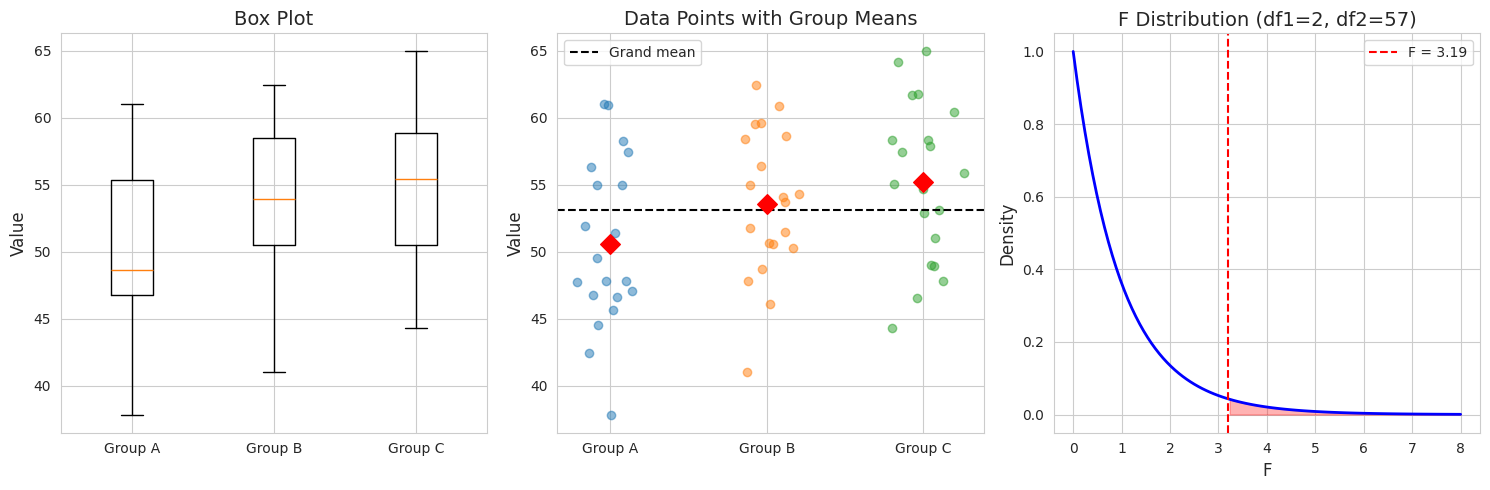

In [3]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot
axes[0].boxplot(groups, labels=group_names)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Box Plot', fontsize=14)

# Individual data points with means
for i, (g, name) in enumerate(zip(groups, group_names)):
    x = np.random.normal(i+1, 0.1, len(g))
    axes[1].scatter(x, g, alpha=0.5)

# Plot means
axes[1].scatter([1, 2, 3], result['group_means'], color='red', s=100, zorder=5, marker='D')
axes[1].axhline(result['grand_mean'], color='black', linestyle='--', label='Grand mean')
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(group_names)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Data Points with Group Means', fontsize=14)
axes[1].legend()

# F distribution
x = np.linspace(0, 8, 100)
y = stats.f.pdf(x, result['df_B'], result['df_W'])
axes[2].plot(x, y, 'b-', linewidth=2)
axes[2].axvline(result['F'], color='red', linestyle='--', label=f'F = {result["F"]:.2f}')
axes[2].fill_between(x[x >= result['F']], y[x >= result['F']], alpha=0.3, color='red')
axes[2].set_xlabel('F', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title(f'F Distribution (df1={result["df_B"]}, df2={result["df_W"]})', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

## 20.2 多重比較

### 問題
ANOVAで有意差が出た後、どの群間に差があるか？

### 方法
1. **テューキーのHSD法**: 全ての対の比較
2. **ボンフェローニ補正**: p値を比較回数で調整
3. **ダネット検定**: 対照群との比較
4. **シェフェ法**: 全ての線形対比

### テューキーのHSD
$$q = \frac{\bar{y}_i - \bar{y}_j}{\sqrt{MS_W/n}}$$

In [4]:
# 多重比較
def tukey_hsd(groups, alpha=0.05):
    """Perform Tukey's HSD test."""
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    
    # Calculate MSE
    group_means = [np.mean(g) for g in groups]
    MSE = sum(np.sum((g - m)**2) for g, m in zip(groups, group_means)) / (n_total - k)
    
    results = []
    
    for i, j in combinations(range(k), 2):
        n_i, n_j = len(groups[i]), len(groups[j])
        mean_diff = group_means[i] - group_means[j]
        
        # Standard error for unequal group sizes
        se = np.sqrt(MSE * (1/n_i + 1/n_j) / 2)
        
        # q statistic (studentized range)
        q = np.abs(mean_diff) / se
        
        # Using t-distribution approximation for p-value
        t_stat = mean_diff / np.sqrt(MSE * (1/n_i + 1/n_j))
        p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), n_total - k))
        
        # Bonferroni correction
        n_comparisons = k * (k - 1) / 2
        p_bonf = min(p_value * n_comparisons, 1.0)
        
        results.append({
            'groups': (i, j),
            'mean_diff': mean_diff,
            'se': se,
            't_stat': t_stat,
            'p_value': p_value,
            'p_bonf': p_bonf
        })
    
    return results

comparisons = tukey_hsd(groups)

print("多重比較（ボンフェローニ補正）")
print("="*70)
print(f"\n{'比較':^15} {'平均差':>10} {'t値':>10} {'p値':>10} {'p(Bonf)':>10}")
print("-"*60)

for comp in comparisons:
    i, j = comp['groups']
    comparison_name = f"{group_names[i]} - {group_names[j]}"
    sig = '*' if comp['p_bonf'] < 0.05 else ''
    print(f"{comparison_name:^15} {comp['mean_diff']:>10.3f} {comp['t_stat']:>10.3f} "
          f"{comp['p_value']:>10.4f} {comp['p_bonf']:>10.4f} {sig}")

多重比較（ボンフェローニ補正）

      比較               平均差         t値         p値    p(Bonf)
------------------------------------------------------------
Group A - Group B     -3.022     -1.616     0.1117     0.3351 
Group A - Group C     -4.658     -2.490     0.0157     0.0471 *
Group B - Group C     -1.636     -0.875     0.3854     1.0000 


## 20.3 二元配置分散分析

### モデル（交互作用あり）
$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

- $\alpha_i$: 因子Aの効果
- $\beta_j$: 因子Bの効果
- $(\alpha\beta)_{ij}$: 交互作用

### 平方和
$$SS_T = SS_A + SS_B + SS_{AB} + SS_E$$

In [5]:
# 二元配置分散分析
np.random.seed(456)

# Two factors: A (3 levels) and B (2 levels)
# With replication

a_levels = 3
b_levels = 2
n_rep = 5

# True effects
mu = 50
alpha = [0, 5, -3]  # Factor A effects
beta = [0, 3]       # Factor B effects
# Interaction effects
interaction = np.array([[0, 0], [2, -2], [-1, 1]])

# Generate data
data = np.zeros((a_levels, b_levels, n_rep))
for i in range(a_levels):
    for j in range(b_levels):
        mean = mu + alpha[i] + beta[j] + interaction[i, j]
        data[i, j] = np.random.normal(mean, 3, n_rep)

def two_way_anova(data):
    """Perform two-way ANOVA with interaction."""
    a, b, n = data.shape
    N = a * b * n
    
    # Means
    grand_mean = np.mean(data)
    A_means = np.mean(data, axis=(1, 2))
    B_means = np.mean(data, axis=(0, 2))
    cell_means = np.mean(data, axis=2)
    
    # Sum of squares
    SS_T = np.sum((data - grand_mean)**2)
    SS_A = b * n * np.sum((A_means - grand_mean)**2)
    SS_B = a * n * np.sum((B_means - grand_mean)**2)
    
    # Interaction
    SS_AB = 0
    for i in range(a):
        for j in range(b):
            SS_AB += n * (cell_means[i,j] - A_means[i] - B_means[j] + grand_mean)**2
    
    SS_E = SS_T - SS_A - SS_B - SS_AB
    
    # Degrees of freedom
    df_A = a - 1
    df_B = b - 1
    df_AB = (a - 1) * (b - 1)
    df_E = a * b * (n - 1)
    
    # Mean squares
    MS_A = SS_A / df_A
    MS_B = SS_B / df_B
    MS_AB = SS_AB / df_AB
    MS_E = SS_E / df_E
    
    # F statistics
    F_A = MS_A / MS_E
    F_B = MS_B / MS_E
    F_AB = MS_AB / MS_E
    
    # p-values
    p_A = 1 - stats.f.cdf(F_A, df_A, df_E)
    p_B = 1 - stats.f.cdf(F_B, df_B, df_E)
    p_AB = 1 - stats.f.cdf(F_AB, df_AB, df_E)
    
    return {
        'SS': {'A': SS_A, 'B': SS_B, 'AB': SS_AB, 'E': SS_E, 'T': SS_T},
        'df': {'A': df_A, 'B': df_B, 'AB': df_AB, 'E': df_E},
        'MS': {'A': MS_A, 'B': MS_B, 'AB': MS_AB, 'E': MS_E},
        'F': {'A': F_A, 'B': F_B, 'AB': F_AB},
        'p': {'A': p_A, 'B': p_B, 'AB': p_AB},
        'cell_means': cell_means
    }

result2 = two_way_anova(data)

print("二元配置分散分析")
print("="*70)
print(f"\n{'Source':<12} {'SS':>10} {'df':>6} {'MS':>10} {'F':>10} {'p-value':>10}")
print("-"*65)

for source in ['A', 'B', 'AB', 'E']:
    if source == 'E':
        print(f"{'Error':<12} {result2['SS'][source]:>10.2f} {result2['df'][source]:>6} "
              f"{result2['MS'][source]:>10.2f}")
    else:
        name = 'Factor A' if source == 'A' else 'Factor B' if source == 'B' else 'A×B'
        print(f"{name:<12} {result2['SS'][source]:>10.2f} {result2['df'][source]:>6} "
              f"{result2['MS'][source]:>10.2f} {result2['F'][source]:>10.2f} "
              f"{result2['p'][source]:>10.4f}")

二元配置分散分析

Source               SS     df         MS          F    p-value
-----------------------------------------------------------------
Factor A         377.21      2     188.61      37.86     0.0000
Factor B         178.07      1     178.07      35.75     0.0000
A×B               10.38      2       5.19       1.04     0.3681
Error            119.55     24       4.98


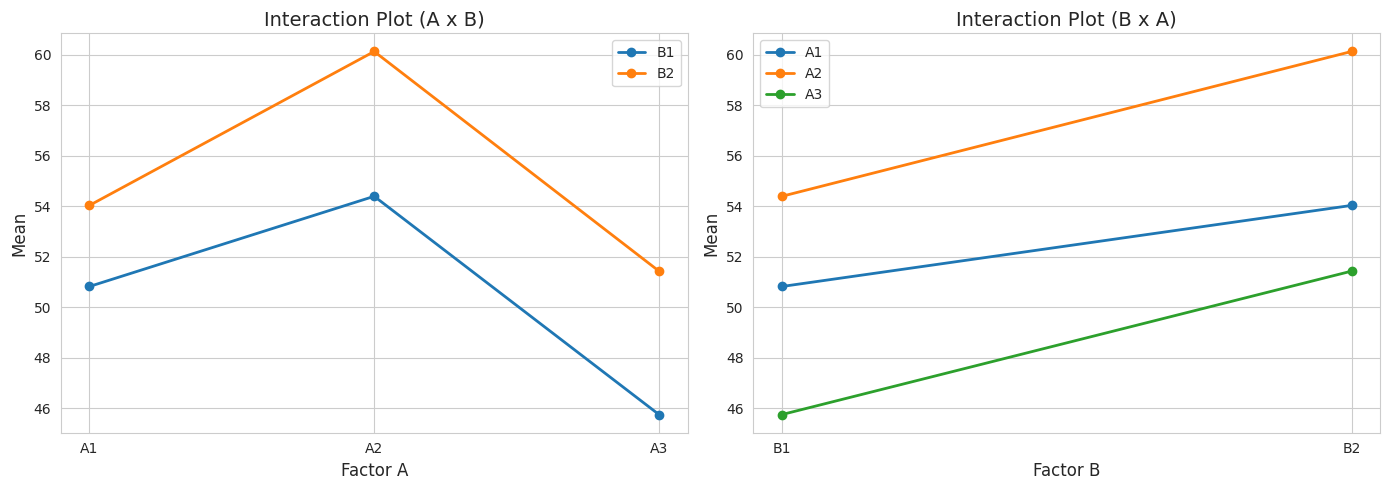


セル平均:
                B1        B2
      A1     50.82     54.03
      A2     54.39     60.12
      A3     45.75     51.43


In [6]:
# 交互作用プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interaction plot (Factor A on x-axis)
for j in range(b_levels):
    axes[0].plot(range(a_levels), result2['cell_means'][:, j], 
                 marker='o', label=f'B{j+1}', linewidth=2)

axes[0].set_xticks(range(a_levels))
axes[0].set_xticklabels([f'A{i+1}' for i in range(a_levels)])
axes[0].set_xlabel('Factor A', fontsize=12)
axes[0].set_ylabel('Mean', fontsize=12)
axes[0].set_title('Interaction Plot (A x B)', fontsize=14)
axes[0].legend()

# Interaction plot (Factor B on x-axis)
for i in range(a_levels):
    axes[1].plot(range(b_levels), result2['cell_means'][i, :], 
                 marker='o', label=f'A{i+1}', linewidth=2)

axes[1].set_xticks(range(b_levels))
axes[1].set_xticklabels([f'B{j+1}' for j in range(b_levels)])
axes[1].set_xlabel('Factor B', fontsize=12)
axes[1].set_ylabel('Mean', fontsize=12)
axes[1].set_title('Interaction Plot (B x A)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nセル平均:")
print(f"{'':>8}" + "".join([f"{'B'+str(j+1):>10}" for j in range(b_levels)]))
for i in range(a_levels):
    print(f"{'A'+str(i+1):>8}" + "".join([f"{result2['cell_means'][i,j]:>10.2f}" 
                                          for j in range(b_levels)]))

## 20.4 変量効果モデル

### 固定効果 vs 変量効果
- **固定効果**: 特定の水準に関心（群間の差を推定）
- **変量効果**: 水準は母集団からの標本（分散成分を推定）

### 変量効果モデル
$$Y_{ij} = \mu + A_i + \varepsilon_{ij}$$

ここで $A_i \sim N(0, \sigma_A^2)$, $\varepsilon_{ij} \sim N(0, \sigma^2)$

### 分散成分の推定
$$\hat{\sigma}^2 = MS_W$$
$$\hat{\sigma}_A^2 = \frac{MS_B - MS_W}{n}$$

変量効果モデル

分散成分の推定:
  σ_E (誤差SD): 真値 = 3, 推定値 = 2.85
  σ_A (群効果SD): 真値 = 4, 推定値 = 3.52

級内相関係数 (ICC) = 0.6042


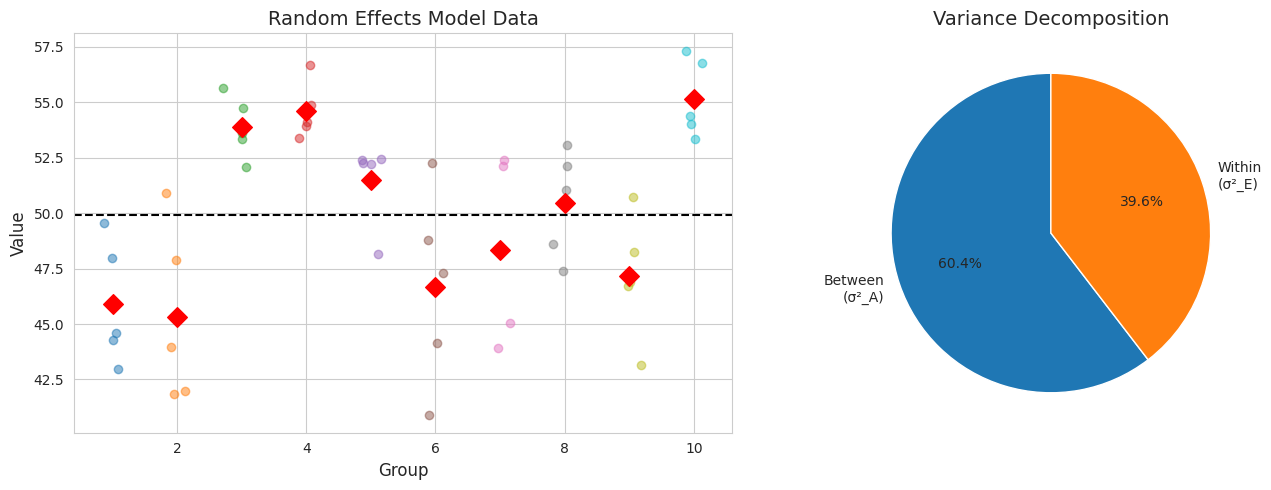

In [7]:
# 変量効果モデル
np.random.seed(789)

# Random effects model
n_groups = 10
n_per_group = 5

sigma_A = 4  # Between-group SD
sigma_E = 3  # Within-group SD

# Generate group effects
group_effects = np.random.normal(0, sigma_A, n_groups)

# Generate data
random_groups = []
for i in range(n_groups):
    group_data = 50 + group_effects[i] + np.random.normal(0, sigma_E, n_per_group)
    random_groups.append(group_data)

# ANOVA
result_random = one_way_anova(random_groups)

# Estimate variance components
sigma_E_hat = np.sqrt(result_random['MS_W'])
sigma_A_hat_sq = (result_random['MS_B'] - result_random['MS_W']) / n_per_group
sigma_A_hat = np.sqrt(max(sigma_A_hat_sq, 0))

# Intraclass correlation
ICC = sigma_A_hat_sq / (sigma_A_hat_sq + result_random['MS_W'])

print("変量効果モデル")
print("="*50)
print(f"\n分散成分の推定:")
print(f"  σ_E (誤差SD): 真値 = {sigma_E}, 推定値 = {sigma_E_hat:.2f}")
print(f"  σ_A (群効果SD): 真値 = {sigma_A}, 推定値 = {sigma_A_hat:.2f}")
print(f"\n級内相関係数 (ICC) = {ICC:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data plot
for i, group in enumerate(random_groups):
    x = np.random.normal(i+1, 0.1, len(group))
    axes[0].scatter(x, group, alpha=0.5)
    axes[0].scatter([i+1], [np.mean(group)], color='red', s=100, marker='D')

axes[0].axhline(result_random['grand_mean'], color='black', linestyle='--')
axes[0].set_xlabel('Group', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Random Effects Model Data', fontsize=14)

# Variance decomposition
labels = ['Between\n(σ²_A)', 'Within\n(σ²_E)']
sizes = [sigma_A_hat**2, sigma_E_hat**2]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Variance Decomposition', fontsize=14)

plt.tight_layout()
plt.show()

## 20.5 要因計画法

### 完全要因計画
全ての因子の全ての水準の組み合わせを試験

### 主効果と交互作用
- **主効果**: 他の因子を平均化したときの因子の効果
- **交互作用**: 因子の効果が他の因子の水準に依存

In [8]:
# 2^3要因計画の例
np.random.seed(111)

# 3 factors, 2 levels each
# Factors: A, B, C (coded as -1, +1)

# Full factorial design
design = np.array([
    [-1, -1, -1],
    [1, -1, -1],
    [-1, 1, -1],
    [1, 1, -1],
    [-1, -1, 1],
    [1, -1, 1],
    [-1, 1, 1],
    [1, 1, 1]
])

# True effects
mu = 50
effect_A = 3
effect_B = 2
effect_C = -1
effect_AB = 1.5
effect_AC = 0
effect_BC = 0
effect_ABC = 0

# Generate responses
n_rep = 3
responses = []

for run in design:
    A, B, C = run
    mean = (mu + effect_A*A + effect_B*B + effect_C*C + 
            effect_AB*A*B + effect_AC*A*C + effect_BC*B*C + effect_ABC*A*B*C)
    y = np.random.normal(mean, 2, n_rep)
    responses.append(y)

responses = np.array(responses)

# Calculate effects
y_mean = responses.mean(axis=1)

# Effect estimates
def calc_effect(design, y, cols):
    """Calculate effect for given columns."""
    contrast = np.prod(design[:, cols], axis=1) if len(cols) > 0 else np.ones(len(design))
    return np.sum(contrast * y) / (len(design) / 2)

print("2^3 要因計画")
print("="*50)
print(f"\n{'効果':>10} {'推定値':>10} {'真値':>10}")
print("-"*35)

effects = [
    ('A', [0], effect_A),
    ('B', [1], effect_B),
    ('C', [2], effect_C),
    ('AB', [0, 1], effect_AB),
    ('AC', [0, 2], effect_AC),
    ('BC', [1, 2], effect_BC),
    ('ABC', [0, 1, 2], effect_ABC)
]

for name, cols, true_val in effects:
    est = calc_effect(design, y_mean, cols)
    print(f"{name:>10} {est:>10.3f} {true_val:>10.1f}")

2^3 要因計画

        効果        推定値         真値
-----------------------------------
         A      5.577        3.0
         B      3.850        2.0
         C     -1.545       -1.0
        AB      2.520        1.5
        AC      0.489        0.0
        BC      0.460        0.0
       ABC     -1.134        0.0


## 20.6 練習問題

### 問題1
4つの肥料を使った植物の成長実験で、以下のデータが得られた。一元配置分散分析を行い、肥料間に差があるか検定せよ。

肥料A: 10, 12, 11, 9, 13
肥料B: 15, 17, 14, 16, 18
肥料C: 12, 11, 13, 10, 14
肥料D: 14, 13, 15, 12, 16

### 問題2
問題1の結果が有意であった場合、どの肥料間に差があるかをボンフェローニ補正を用いて調べよ。

### 問題3
固定効果モデルと変量効果モデルの違いを説明せよ。

In [9]:
# 問題1の解答
print("問題1: 一元配置分散分析")
print("="*60)

fertA = np.array([10, 12, 11, 9, 13])
fertB = np.array([15, 17, 14, 16, 18])
fertC = np.array([12, 11, 13, 10, 14])
fertD = np.array([14, 13, 15, 12, 16])

fertilizers = [fertA, fertB, fertC, fertD]
fert_names = ['肥料A', '肥料B', '肥料C', '肥料D']

result = one_way_anova(fertilizers)

print(f"\n群の平均:")
for name, mean in zip(fert_names, result['group_means']):
    print(f"  {name}: {mean:.2f}")

print(f"\nF = {result['F']:.4f}")
print(f"p値 = {result['p_value']:.6f}")
print(f"\n結論: p = {result['p_value']:.6f} < 0.05 なので、肥料間に有意な差がある")

問題1: 一元配置分散分析

群の平均:
  肥料A: 11.00
  肥料B: 16.00
  肥料C: 12.00
  肥料D: 14.00

F = 9.8333
p値 = 0.000647

結論: p = 0.000647 < 0.05 なので、肥料間に有意な差がある


In [10]:
# 問題2の解答
print("問題2: 多重比較（ボンフェローニ補正）")
print("="*60)

comparisons = tukey_hsd(fertilizers)

print(f"\n{'比較':^15} {'平均差':>10} {'p(Bonf)':>10} {'有意':>8}")
print("-"*50)

for comp in comparisons:
    i, j = comp['groups']
    comparison_name = f"{fert_names[i][-1]} - {fert_names[j][-1]}"
    sig = '***' if comp['p_bonf'] < 0.001 else '**' if comp['p_bonf'] < 0.01 else '*' if comp['p_bonf'] < 0.05 else ''
    print(f"{comparison_name:^15} {comp['mean_diff']:>10.3f} {comp['p_bonf']:>10.4f} {sig:>8}")

print(f"\n結論: 肥料Bと他の肥料間に有意な差がある")

問題2: 多重比較（ボンフェローニ補正）

      比較               平均差    p(Bonf)       有意
--------------------------------------------------
     A - B          -5.000     0.0008      ***
     A - C          -1.000     1.0000         
     A - D          -3.000     0.0509         
     B - C           4.000     0.0062       **
     B - D           2.000     0.3766         
     C - D          -2.000     0.3766         

結論: 肥料Bと他の肥料間に有意な差がある


In [11]:
# 問題3の解答
print("問題3: 固定効果モデルと変量効果モデルの比較")
print("="*60)

print("""
【固定効果モデル】
- 因子の水準が特定のものに固定されている
- 例: 特定の3種類の肥料の効果を比較
- 推定対象: 各水準の効果（α_i）
- 結論は使用した水準にのみ適用

【変量効果モデル】
- 因子の水準が母集団からの無作為標本
- 例: 無作為に選んだ10人の教師の効果
- 推定対象: 分散成分（σ²_A）
- 結論は母集団全体に一般化可能

【F検定における違い】
- 固定効果: F = MS_A / MS_E
- 変量効果: 同じ（一元配置の場合）
  ただし混合モデルでは異なる分母を使用

【選択基準】
- 特定の水準に関心 → 固定効果
- 母集団の変動に関心 → 変量効果
""")

問題3: 固定効果モデルと変量効果モデルの比較

【固定効果モデル】
- 因子の水準が特定のものに固定されている
- 例: 特定の3種類の肥料の効果を比較
- 推定対象: 各水準の効果（α_i）
- 結論は使用した水準にのみ適用

【変量効果モデル】
- 因子の水準が母集団からの無作為標本
- 例: 無作為に選んだ10人の教師の効果
- 推定対象: 分散成分（σ²_A）
- 結論は母集団全体に一般化可能

【F検定における違い】
- 固定効果: F = MS_A / MS_E
- 変量効果: 同じ（一元配置の場合）
  ただし混合モデルでは異なる分母を使用

【選択基準】
- 特定の水準に関心 → 固定効果
- 母集団の変動に関心 → 変量効果



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---